# 🚲 Bike Rental Prediction


## 1. Загрузка данных

In [1]:
!pip install gdown -q

import gdown
import pandas as pd
import numpy as np

file_id = "1-4wgz9AFXrD3tZfqHJLMhCmy4BUzAX96"
url = f"https://drive.google.com/uc?id={file_id}"

output = "bikes_rent.csv"
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1-4wgz9AFXrD3tZfqHJLMhCmy4BUzAX96
To: /content/bikes_rent.csv
100%|██████████| 50.3k/50.3k [00:00<00:00, 23.1MB/s]


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


## 2. Первичный анализ

In [2]:
print(df.shape)
df.info()
df.describe()

(731, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          731 non-null    int64  
 1   yr              731 non-null    int64  
 2   mnth            731 non-null    int64  
 3   holiday         731 non-null    int64  
 4   weekday         731 non-null    int64  
 5   workingday      731 non-null    int64  
 6   weathersit      731 non-null    int64  
 7   temp            731 non-null    float64
 8   atemp           731 non-null    float64
 9   hum             731 non-null    float64
 10  windspeed(mph)  731 non-null    float64
 11  windspeed(ms)   731 non-null    float64
 12  cnt             731 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 74.4 KB


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,20.310776,23.717699,62.789406,12.762576,5.705220,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,7.505091,8.148059,14.242910,5.192357,2.321125,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,0.670650,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.820424,16.892125,52.000000,9.041650,4.041864,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,20.431653,24.336650,62.666700,12.125325,5.420351,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.872076,30.430100,73.020850,15.625371,6.984967,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,15.198937,8714.000000


## 3. Проверка данных

In [3]:
print("Пропуски:")
print(df.isnull().sum())

print("\nДубликаты:", df.duplicated().sum())

Пропуски:
season            0
yr                0
mnth              0
holiday           0
weekday           0
workingday        0
weathersit        0
temp              0
atemp             0
hum               0
windspeed(mph)    0
windspeed(ms)     0
cnt               0
dtype: int64

Дубликаты: 0


## 4. Предобработка

In [4]:
cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


## 5. Разделение данных

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['cnt'])
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((584, 12), (147, 12))

## 6. Масштабирование

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 623.8153055903182
RMSE: 830.5580466117005
R2: 0.827968349406303


## 8. Random Forest

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 425.59622641862046
RMSE: 673.6667074577797
R2: 0.8868229039966843


## 9. Gradient Boosting

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2:", r2_score(y_test, y_pred_gb))

Gradient Boosting
MAE: 463.2712208853714
RMSE: 660.7306718659697
R2: 0.8911277216322782


## 10. Сравнение моделей

In [10]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,623.815306,830.558047,0.827968
1,Random Forest,425.596226,673.666707,0.886823
2,Gradient Boosting,463.271221,660.730672,0.891128


## 11. Визуализация

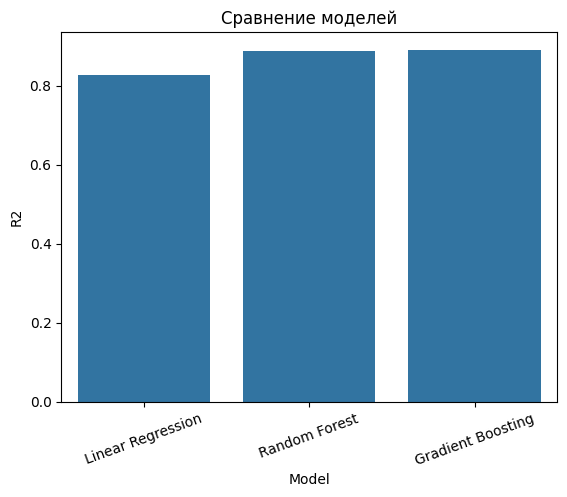

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.barplot(data=results, x="Model", y="R2")
plt.title("Сравнение моделей")
plt.xticks(rotation=20)
plt.show()

## 12. Важность признаков

In [12]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
7,temp,0.346093
1,yr,0.280709
8,atemp,0.154648
9,hum,0.058052
0,season,0.055492
2,mnth,0.029079
6,weathersit,0.018781
11,windspeed(ms),0.017442
10,windspeed(mph),0.016699
4,weekday,0.015772


1. Загрузка и ознакомление с данными

Был загружен датасет с информацией об аренде велосипедов. Проведён первичный анализ:

определён размер выборки
изучены типы данных
рассчитаны базовые статистики
2. Очистка данных

Выполнена проверка на:

пропущенные значения
дубликаты

Удалены неинформативные признаки:

instant
dteday
casual
registered

3. Подготовка данных
выделена целевая переменная: cnt (общее число аренд)
сформированы признаки (features)
данные разделены на обучающую и тестовую выборки (80/20)
4. Масштабирование признаков

Применена стандартизация с использованием StandardScaler для улучшения работы линейной модели.

5. Построение моделей

Были обучены три модели:

Линейная регрессия (Linear Regression)
Случайный лес (Random Forest)
Градиентный бустинг (Gradient Boosting)
6. Оценка моделей

Для оценки качества использовались метрики:

MAE (средняя абсолютная ошибка)
RMSE (корень из средней квадратичной ошибки)
R² (коэффициент детерминации)

Проведено сравнение моделей по этим показателям.

7. Визуализация результатов

Построены графики:

сравнение моделей по R²
зависимость предсказанных значений от реальных
важность признаков
8. Анализ важности признаков

С помощью модели случайного леса определены наиболее значимые факторы, влияющие на количество аренд.

9. Итог
построены и сравнены несколько моделей
выбрана наиболее точная модель
определены ключевые факторы, влияющие на спрос